# MNIST Image dataset

The MNIST dataset contains digits from 0 to 9 written in different handstyles. This is a multiclass classifcation problem.
The code runs by itself only change is the path mydir (Documented below).

## installations
<ul>
<li>pip install torchvision (check last point on how to install the right way if you want to include cuda compatible)
<li>pip install torch
<li> pip install matplotlib (For plotting)
<li>go to https://pytorch.org/get-started/locally/?utm_source=chatgpt.com and download cuda version for your device.
</ul>




In [1]:
import kagglehub    
import numpy as np # linear algebra
import struct
import torch
from os.path  import join
from torch import nn
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from torchvision.transforms import ToTensor, v2, Compose, RandomCrop

## DownLoad the dataset and conduct data agumentation and transformation to tensor. 
### Minst dataset consist of hand-written digits from 0 to 9 written in different hand-styles.
Download, convert to tensor, random crop the images

In [2]:
mydir=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\labs\Computer-Vision\images\dataset" # this should be changed to a directory on your device
train_data=datasets.MNIST( 
    root=mydir,
    download=True,
    train=True,
    transform=Compose([
        RandomCrop(size=24),
        ToTensor()
    ])
)
test_data=datasets.MNIST(
    root=mydir,
    download=True,
    train=False,
    transform=Compose([
        RandomCrop(size=24),
        ToTensor()
    ])
)


### Check if cuda is available on device

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [4]:
train_data[0][0].size()

torch.Size([1, 24, 24])

In [5]:
image, label=train_data[8]
print(type(train_data[5]))
print(label,"===\n")
print(type(image))
train_set,val_set=torch.utils.data.random_split(train_data, [5/6,1/6])
len(train_set)

<class 'tuple'>
1 ===

<class 'torch.Tensor'>


50000

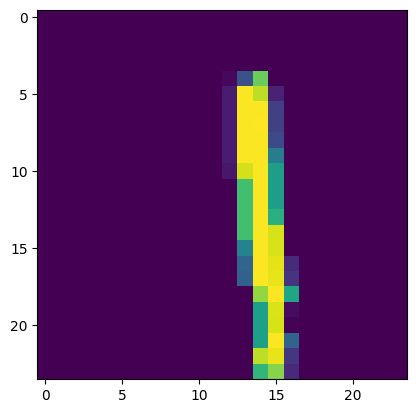

In [6]:
plt.imshow(image[0])

### Create a DataLoader with batch_size=64 

In [7]:
train_dataloader = DataLoader(train_set, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size=1000, shuffle=True)

test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)


In [8]:
image, label= next(iter(train_dataloader))
image.size()

torch.Size([64, 1, 24, 24])

# Design the Neural Network 
<li> CNN is inheriting from torch.nn.Module base class
<li> Define cnn layers
<li> Define activation-layer for each layer to ReLU (Rectified Linear Unit) Not needed but can be used
<li> nn.Sequential is a container that containes the hidden layers in order from top down
<li> The forward step tells the compiler to flatten the tensor to 1D (32 * 1 * 1) then run the module.

In [9]:
class cnn(nn.Module):
    def __init__(self):
        super().__init__()
       
       #sequentail contianer to contain the pipeline of the hidden layer
        self.cnn=nn.Sequential(
           #block1
            nn.Conv2d(1,16,3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),

            #block2
            nn.Conv2d(16,32,3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2)

        )
        self.fully_connected=nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 1 * 1,10)
            
        )
        

    def forward(self, x):
        x=self.cnn(x)
        x=self.fully_connected(x)
        return x

<li> Moves the module to cuda device so the module run the weights and parameters to GPU
<li> Chose loss-functions (CrossEntropyLoss because we have multiclass prediction)
<li> Chose optimizer and configure learning rate and momentum

In [10]:
cnn=cnn().to(device)

loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)




## Training function
<li> Moves input and output to cuda device.
<li> Set the gradient to Nan after every batch to not include past behaviour (accumulated calcultaed gradient )in new training patch. 
<li> Predict x
<li> Calculate loss
<li> loss.backward() computes the gradient of current tensor. (calculate the gradient for every parameter w.r.t loss) 
<li> Optimizer.step() Update parameters based on the calculated gradient


In [11]:
def training_loop(module , train_loader, val_dataloader, loss_fn, optimizer=None):
    
    if optimizer == None:
        optimizer = torch.optim.SGD(module.parameters(), lr=0.001, momentum=0.9)
    module.train()
    running_loss = 0.0
    total_loss=0.0
    for batch, (X,y) in enumerate(train_loader):
        X, y= X.to(device), y.to(device)
        optimizer.zero_grad()
        pred=module(X)
        loss=loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        running_loss +=loss.item()
        total_loss +=loss.item()
        if batch % 100 == 0:    
            print(f'[ {batch + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0


    module.eval()
    with torch.no_grad():
        total_val_loss=0
        for im, l in val_dataloader:
            X_val=im.to(device) 
            y_val=l.to(device)
       
            val_pred=module(X_val)
            val_loss=loss_fn(val_pred,y_val)
            
            total_val_loss+=val_loss
    
        print(f'training_loss: {total_loss:.3f}: validaton_loss: {total_val_loss:.3f}')


    print('Finished Training')
       

## Test function
Make prediction on unseen data then calcuulate accuracy

In [12]:
def test_loop(module, dataloader, loss_fn):
    module.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = module(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    print(f'Accuracy of the network on the test images: {accuracy:.2f}%, Test loss: {avg_loss:.3f}')

### Run the module
<li> Define number of epoch and run training


In [13]:
epoch=10
for i in range(epoch):
    training_loop(cnn,train_dataloader,val_dataloader,loss_fn,optimizer)

[     1] loss: 0.029
[   101] loss: 1.831
[   201] loss: 1.139
[   301] loss: 0.797
[   401] loss: 0.611
[   501] loss: 0.512
[   601] loss: 0.437
[   701] loss: 0.389
training_loss: 603.329: validaton_loss: 3.624
Finished Training
[     1] loss: 0.004
[   101] loss: 0.332
[   201] loss: 0.324
[   301] loss: 0.308
[   401] loss: 0.286
[   501] loss: 0.279
[   601] loss: 0.244
[   701] loss: 0.242
training_loss: 221.336: validaton_loss: 2.416
Finished Training
[     1] loss: 0.001
[   101] loss: 0.241
[   201] loss: 0.213
[   301] loss: 0.224
[   401] loss: 0.199
[   501] loss: 0.211
[   601] loss: 0.203
[   701] loss: 0.199
training_loss: 164.670: validaton_loss: 1.921
Finished Training
[     1] loss: 0.002
[   101] loss: 0.192
[   201] loss: 0.188
[   301] loss: 0.183
[   401] loss: 0.176
[   501] loss: 0.188
[   601] loss: 0.190
[   701] loss: 0.174
training_loss: 142.991: validaton_loss: 1.748
Finished Training
[     1] loss: 0.001
[   101] loss: 0.182
[   201] loss: 0.173
[   301] 

## Run the module on test data


In [14]:
test_loop(cnn, test_dataloader,loss_fn)

Accuracy of the network on the test images: 96.42%, Test loss: 0.112
